1. En el preprocesamiento debe mostrar cuantos ejemplares hay por cada familia. En base a
estos datos debe determinar si considera pertinente prescindir de ejemplares que tengan
pocas observaciones

,count
Allaple.A,2949
Allaple.L,1591
Yuner.A,800
Instantaccess,431
VB.AT,408
Fakerean,381
Lolyda.AA1,213
C2LOP.gen!g,200
Alueron.gen!J,198
Lolyda.AA2,184


<Figure size 1200x400 with 0 Axes>

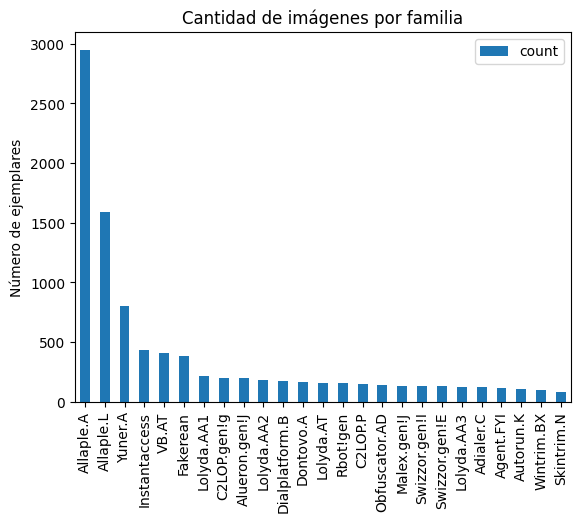

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt


root_dir = "malimg_dataset"
imgs_dir = os.path.join(root_dir,
    next(d for d in os.listdir(root_dir)
         if os.path.isdir(os.path.join(root_dir, d)) and d.endswith("_imgs"))
)

familias = [d for d in os.listdir(imgs_dir)
            if os.path.isdir(os.path.join(imgs_dir, d))]
conteos = {
    fam: len([
        f for f in os.listdir(os.path.join(imgs_dir, fam))
        if f.lower().endswith(".png")
    ])
    for fam in familias
}

df = (pd.DataFrame.from_dict(conteos, orient="index", columns=["count"])
        .sort_values("count", ascending=False))
display(df)

plt.figure(figsize=(12,4))
df.plot.bar()
plt.ylabel("Número de ejemplares")
plt.title("Cantidad de imágenes por familia")
plt.show()


In [ ]:
# Familias con al menos 100 imagenes
threshold = 100

#Familias con count >= threshold
familias_sel = df[df["count"] >= threshold].index.tolist()
print("Familias que conservamos (>= 100 imágenes):")
print(familias_sel)


Familias que conservamos (>= 100 imágenes):
['Allaple.A', 'Allaple.L', 'Yuner.A', 'Instantaccess', 'VB.AT', 'Fakerean', 'Lolyda.AA1', 'C2LOP.gen!g', 'Alueron.gen!J', 'Lolyda.AA2', 'Dialplatform.B', 'Dontovo.A', 'Lolyda.AT', 'Rbot!gen', 'C2LOP.P', 'Obfuscator.AD', 'Malex.gen!J', 'Swizzor.gen!I', 'Swizzor.gen!E', 'Lolyda.AA3', 'Adialer.C', 'Agent.FYI', 'Autorun.K']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3
)

train_gen = datagen.flow_from_directory(
    imgs_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=familias_sel, 
    class_mode="sparse",
    subset="training",
    seed=42
)


val_gen = datagen.flow_from_directory(
    imgs_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=familias_sel,
    class_mode="sparse",
    subset="validation",
    seed=42
)

print("Clases finales:", list(train_gen.class_indices.keys()))



Found 6425 images belonging to 23 classes.
Found 2737 images belonging to 23 classes.
Clases finales: ['Allaple.A', 'Allaple.L', 'Yuner.A', 'Instantaccess', 'VB.AT', 'Fakerean', 'Lolyda.AA1', 'C2LOP.gen!g', 'Alueron.gen!J', 'Lolyda.AA2', 'Dialplatform.B', 'Dontovo.A', 'Lolyda.AT', 'Rbot!gen', 'C2LOP.P', 'Obfuscator.AD', 'Malex.gen!J', 'Swizzor.gen!I', 'Swizzor.gen!E', 'Lolyda.AA3', 'Adialer.C', 'Agent.FYI', 'Autorun.K']


2. Plotee algunas imágenes de los ejemplos de malware

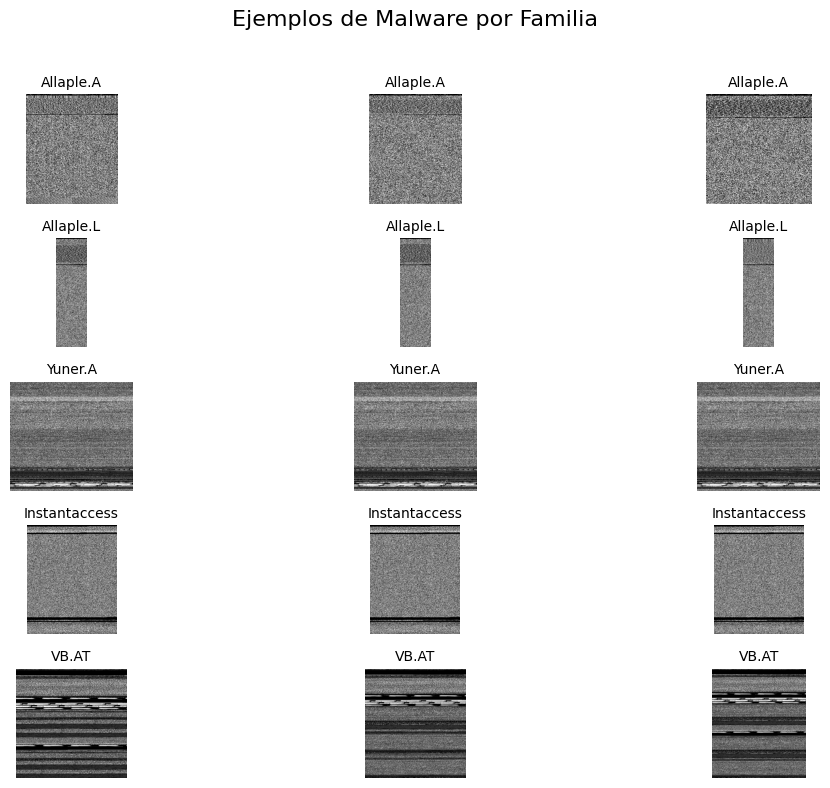

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Parámetros de visualización
samples_per_class = 3
classes_to_plot = familias_sel[:5]  # toma las primeras 5 familias 

plt.figure(figsize=(12, 8))

for row, fam in enumerate(classes_to_plot):
    fam_dir = os.path.join(imgs_dir, fam)
    imgs = random.sample([f for f in os.listdir(fam_dir) if f.lower().endswith(".png")],
                        samples_per_class)
    for col, img_name in enumerate(imgs):
        img_path = os.path.join(fam_dir, img_name)
        img = Image.open(img_path)
        
        ax = plt.subplot(len(classes_to_plot), samples_per_class,
                         row * samples_per_class + col + 1)
        ax.imshow(img, cmap="gray")
        ax.set_title(fam, fontsize=10)
        ax.axis("off")

plt.suptitle("Ejemplos de Malware por Familia", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


3. Utilizando Keras y Tensorflow construya una red neuronal con las capas, funciones de
activación y el optimizador que considere conveniente

4. Muestre el resumen del modelo.

In [ ]:
from tensorflow.keras import models, layers


IMG_SIZE = (128, 128)  
NUM_CLASSES = len(familias_sel) 

# 3. Construcción de la red neuronal
model = models.Sequential([
    # Normalización de píxeles
    layers.Rescaling(1./255, input_shape=(*IMG_SIZE, 3)),

    # Bloque conv 1
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Bloque conv 2
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Bloque conv 3
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Aplanado y densas finales
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    # Capa de salida
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Optimizer y compilación
model.compile(
    optimizer="adam",                                 
    loss="sparse_categorical_crossentropy",             
    metrics=["accuracy"]
)


model.summary()


C:\Users\marce\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,488,023 (32.38 MB)

 Trainable params: 8,488,023 (32.38 MB)

 Non-trainable params: 0 (0.00 B)

5. Divida el dataset en un 70% entrenamiento y un 30% de pruebas.
6. Entrene el modelo con el número de épocas que considere conveniente.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Parámetros
IMG_SIZE    = (128,128)
BATCH_SIZE  = 32
EPOCHS      = 20       

# 5. DIVISIÓN 70/30
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.3   # 30% validation
)

train_gen = datagen.flow_from_directory(
    imgs_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=familias_sel,
    class_mode="sparse",
    subset="training",  
    seed=42
)

val_gen = datagen.flow_from_directory(
    imgs_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    classes=familias_sel,
    class_mode="sparse",
    subset="validation",  
    seed=42
)

es = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[es]
)


Found 6425 images belonging to 23 classes.
Found 2737 images belonging to 23 classes.


C:\Users\marce\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.2957 - loss: 2.6063 - val_accuracy: 0.3230 - val_loss: 2.5451
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.3642 - loss: 2.1724 - val_accuracy: 0.7143 - val_loss: 0.8564
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 139ms/step - accuracy: 0.7113 - loss: 0.8860 - val_accuracy: 0.8729 - val_loss: 0.3884
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.8405 - loss: 0.4950 - val_accuracy: 0.9068 - val_loss: 0.2741
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.9047 - loss: 0.3136 - val_accuracy: 0.9335 - val_loss: 0.2202
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.9167 - loss: 0.2547 - val_accuracy: 0.9408 - val_loss: 0.1892
Epoch 7/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 142ms/step - accuracy: 0.9309 - loss: 0.2154 - val_accuracy: 0.9507 - val_loss: 0.1709
Epoch 8/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.9342 - loss: 0

7. Muestre las métricas de su modelo

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
0,0.308327,2.534559,0.322981,2.545067
1,0.449027,1.786961,0.714286,0.856387
2,0.765914,0.724665,0.872854,0.388359
3,0.854319,0.465213,0.906832,0.274066
4,0.904124,0.307803,0.933504,0.220206
5,0.915331,0.259240,0.940811,0.189243
6,0.927315,0.226813,0.950676,0.170945
7,0.932140,0.204638,0.951407,0.166091
8,0.944903,0.171927,0.951041,0.166835


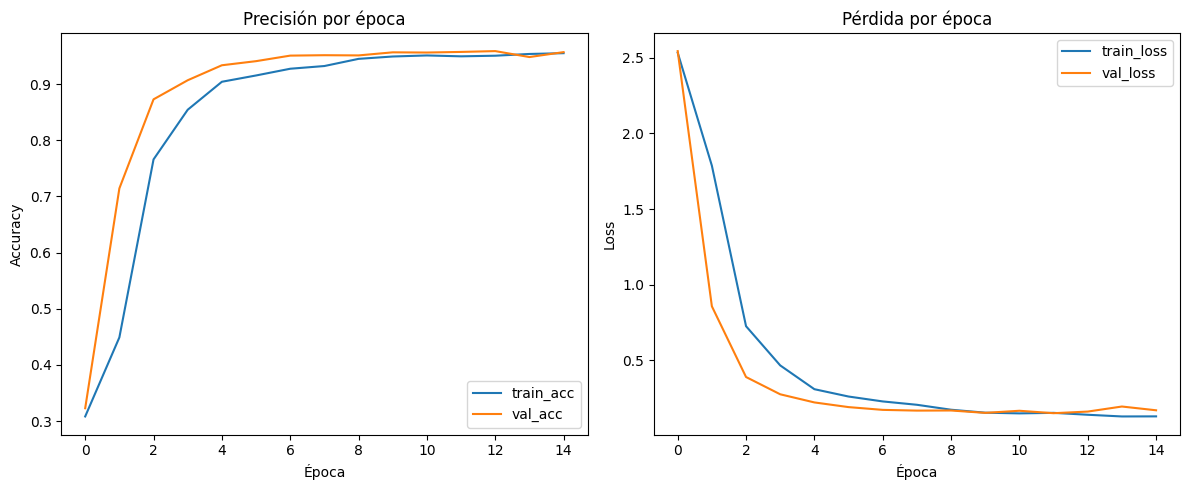

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame(history.history)
metrics_df.index.name = "epoch"
display(metrics_df)


plt.figure(figsize=(12,5))

# Precisión
plt.subplot(1,2,1)
plt.plot(metrics_df["accuracy"], label="train_acc")
plt.plot(metrics_df["val_accuracy"], label="val_acc")
plt.title("Precisión por época")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

# Pérdida
plt.subplot(1,2,2)
plt.plot(metrics_df["loss"], label="train_loss")
plt.plot(metrics_df["val_loss"], label="val_loss")
plt.title("Pérdida por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


C:\Users\marce\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step


,Allaple.A,Allaple.L,Yuner.A,Instantaccess,VB.AT,Fakerean,Lolyda.AA1,C2LOP.gen!g,Alueron.gen!J,Lolyda.AA2,...,Rbot!gen,C2LOP.P,Obfuscator.AD,Malex.gen!J,Swizzor.gen!I,Swizzor.gen!E,Lolyda.AA3,Adialer.C,Agent.FYI,Autorun.K
Allaple.A,298,147,95,32,42,40,18,26,18,21,...,13,14,14,12,10,13,7,12,12,0
Allaple.L,143,92,49,25,24,21,15,14,7,6,...,3,4,10,11,5,7,3,8,4,0
Yuner.A,70,43,27,15,16,10,5,6,9,6,...,6,2,2,2,1,2,4,2,4,0
Instantaccess,34,28,11,4,6,2,2,3,5,2,...,3,4,2,2,1,0,5,2,1,0
VB.AT,39,19,7,9,3,8,6,2,4,3,...,3,3,0,1,1,3,3,1,2,0
Fakerean,49,14,12,5,4,2,1,1,6,1,...,1,1,1,1,3,0,1,0,0,0
Lolyda.AA1,28,10,3,2,1,0,3,2,1,1,...,1,3,2,0,1,0,1,0,1,0
C2LOP.gen!g,28,8,3,1,2,3,3,0,1,2,...,4,0,1,1,0,1,0,1,1,0
Alueron.gen!J,24,2,3,3,4,4,2,1,0,2,...,4,0,1,3,0,1,1,0,1,0
Lolyda.AA2,15,16,7,2,0,3,1,1,2,1,...,3,0,0,0,1,0,0,1,1,0


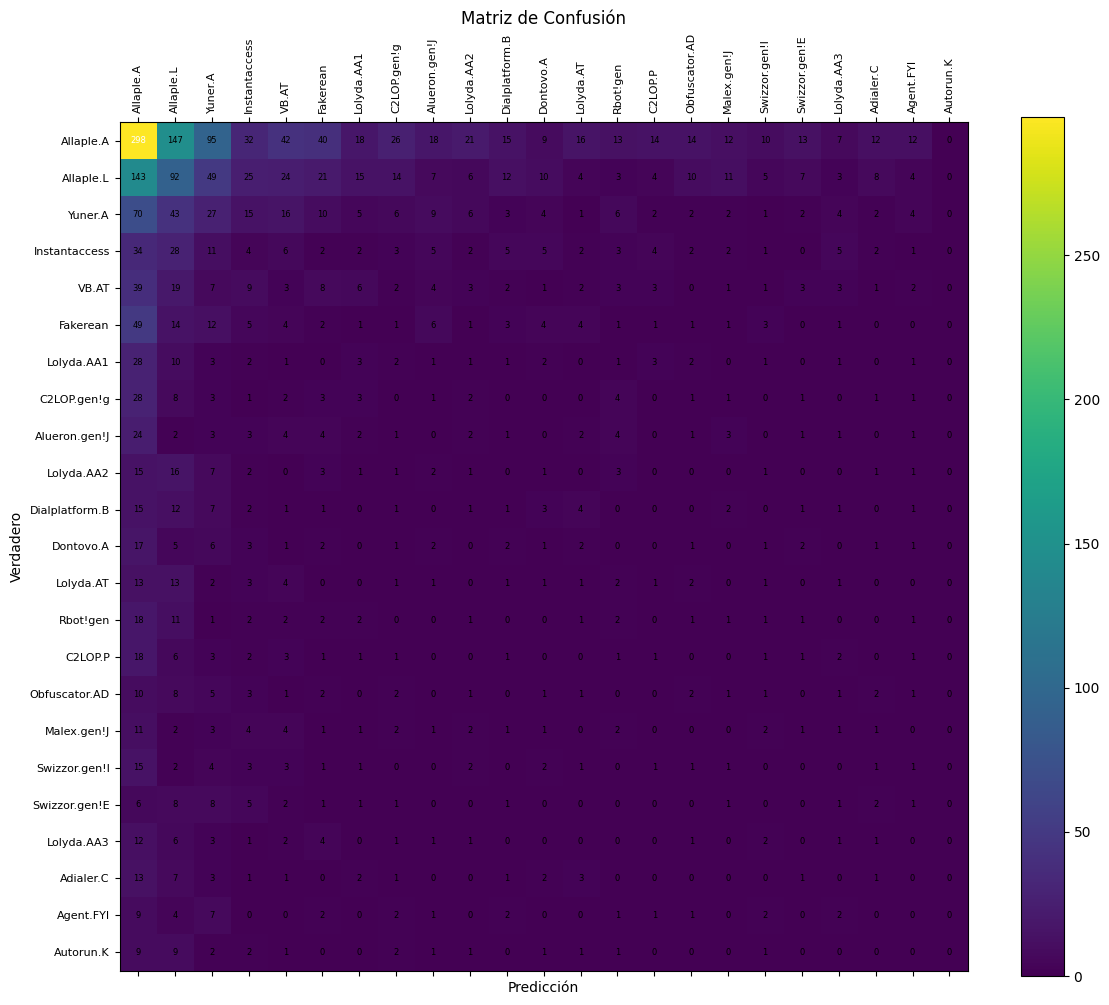

In [29]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


val_gen.reset()
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)


class_names = list(val_gen.class_indices.keys())


cm_tf = tf.math.confusion_matrix(
    labels=y_true,
    predictions=y_pred,
    num_classes=len(class_names)
)
cm = cm_tf.numpy()


cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
display(cm_df)


fig, ax = plt.subplots(figsize=(12,10))
cax = ax.matshow(cm, interpolation='nearest')
fig.colorbar(cax)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=90, fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
ax.set_xlabel("Predicción")
ax.set_ylabel("Verdadero")
ax.set_title("Matriz de Confusión")


for (i, j), val in np.ndenumerate(cm):
    color = "white" if val > cm.max()/2 else "black"
    ax.text(j, i, val, ha="center", va="center", fontsize=6, color=color)

plt.tight_layout()
plt.show()


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

# Parámetros
IMGS_DIR   = "malimg_dataset/malimg_paper_dataset_imgs"
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 50


FAMILIAS_23 = [
    'Allaple.A','Allaple.L','Yuner.A','Instantaccess','VB.AT','Fakerean',
    'Lolyda.AA1','C2LOP.gen!g','Alueron.gen!J','Lolyda.AA2','Dialplatform.B',
    'Dontovo.A','Lolyda.AT','Rbot!gen','C2LOP.P','Obfuscator.AD','Malex.gen!J',
    'Swizzor.gen!I','Swizzor.gen!E','Lolyda.AA3','Adialer.C','Agent.FYI','Autorun.K'
]


train_ds = tf.keras.utils.image_dataset_from_directory(
    IMGS_DIR,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=FAMILIAS_23,
    shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    IMGS_DIR,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=FAMILIAS_23,
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

# 3) Data augmentation con tf.data
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def preprocess(ds, train=True):
    ds = ds.map(lambda x, y: (data_augmentation(x), y), 
                num_parallel_calls=tf.data.AUTOTUNE) if train else ds
    ds = ds.map(lambda x, y: (x/255.0, y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = preprocess(train_ds, train=True)
val_ds   = preprocess(val_ds,   train=False)

# 4) Cálculo de class_weight
counts = np.bincount(np.concatenate([y.numpy() for x,y in train_ds], axis=0))
total = counts.sum()
class_weight = {i: total/(NUM_CLASSES * c) for i, c in enumerate(counts)}

base = tf.keras.applications.MobileNetV2(input_shape=(*IMG_SIZE,3), include_top=False, weights="imagenet")
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

inputs = layers.Input(shape=(*IMG_SIZE,3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint = callbacks.ModelCheckpoint("best_tl_model.h5", monitor="val_loss", save_best_only=True, verbose=1)
earlystop   = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[checkpoint, earlystop]
)


Found 9162 files belonging to 23 classes.
Using 6414 files for training.
Found 9162 files belonging to 23 classes.
Using 2748 files for validation.
Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6861 - loss: 1.2250
Epoch 1: val_loss improved from inf to 3.44489, saving model to best_tl_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 38s 165ms/step - accuracy: 0.6866 - loss: 1.2228 - val_accuracy: 0.5033 - val_loss: 3.4449
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8629 - loss: 0.4320
Epoch 2: val_loss did not improve from 3.44489
201/201 ━━━━━━━━━━━━━━━━━━━━ 42s 167ms/step - accuracy: 0.8630 - loss: 0.4319 - val_accuracy: 0.2587 - val_loss: 9.0485
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8843 - loss: 0.3181
Epoch 3: val_loss did not improve from 3.44489
201/201 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - accuracy: 0.8843 - loss: 0.3182 - val_accuracy: 0.3432 - val_loss: 4.3823
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8969 - loss: 0.2699
Epoch 4: val_loss did not improve from 3.44489
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.8969 - loss: 0.2700 - val_accuracy: 0.5197 - val_loss: 4.3057
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9026 - loss: 0.2381
Epoch 5: val_loss improved 

201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.9026 - loss: 0.2382 - val_accuracy: 0.5983 - val_loss: 2.2123
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9036 - loss: 0.2549
Epoch 6: val_loss improved from 2.21235 to 1.17165, saving model to best_tl_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.9036 - loss: 0.2550 - val_accuracy: 0.7489 - val_loss: 1.1717
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8853 - loss: 0.3116
Epoch 7: val_loss did not improve from 1.17165
201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 166ms/step - accuracy: 0.8854 - loss: 0.3115 - val_accuracy: 0.6277 - val_loss: 2.5520
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8983 - loss: 0.2254
Epoch 8: val_loss improved from 1.17165 to 0.39697, saving model to best_tl_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 164ms/step - accuracy: 0.8983 - loss: 0.2254 - val_accuracy: 0.8512 - val_loss: 0.3970
Epoch 9/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9099 - loss: 0.2480
Epoch 9: val_loss did not improve from 0.39697
201/201 ━━━━━━━━━━━━━━━━━━━━ 31s 155ms/step - accuracy: 0.9099 - loss: 0.2479 - val_accuracy: 0.7584 - val_loss: 0.9283
Epoch 10/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9133 - loss: 0.2052
Epoch 10: val_loss improved from 0.39697 to 0.31307, saving model to best_tl_model.h5


201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - accuracy: 0.9133 - loss: 0.2053 - val_accuracy: 0.9105 - val_loss: 0.3131
Epoch 11/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8978 - loss: 0.2610
Epoch 11: val_loss did not improve from 0.31307
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.8978 - loss: 0.2612 - val_accuracy: 0.2755 - val_loss: 9.4429
Epoch 12/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9055 - loss: 0.2118
Epoch 12: val_loss did not improve from 0.31307
201/201 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.9055 - loss: 0.2119 - val_accuracy: 0.6870 - val_loss: 2.6327
Epoch 13/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9027 - loss: 0.2156
Epoch 13: val_loss did not improve from 0.31307
201/201 ━━━━━━━━━━━━━━━━━━━━ 32s 160ms/step - accuracy: 0.9028 - loss: 0.2157 - val_accuracy: 0.4873 - val_loss: 4.9809
Epoch 14/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8964 - loss: 0.2868
Epoch 14: val_loss d

8. Evalúe el modelo con el dataset de pruebas y muestre las métricas obtenidas. Discuta los
resultados obtenidos.


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf


CLASS_NAMES = [
    'Allaple.A','Allaple.L','Yuner.A','Instantaccess','VB.AT','Fakerean',
    'Lolyda.AA1','C2LOP.gen!g','Alueron.gen!J','Lolyda.AA2','Dialplatform.B',
    'Dontovo.A','Lolyda.AT','Rbot!gen','C2LOP.P','Obfuscator.AD','Malex.gen!J',
    'Swizzor.gen!I','Swizzor.gen!E','Lolyda.AA3','Adialer.C','Agent.FYI','Autorun.K'
]


loss, acc = model.evaluate(val_ds, verbose=1)
print(f"\nTest Loss: {loss:.4f}   Test Accuracy: {acc:.4f}\n")

y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)
y_pred = np.argmax(model.predict(val_ds, verbose=0), axis=1)


cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(CLASS_NAMES)).numpy()
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
print("Confusion Matrix:\n")
print(cm_df.to_string())


tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
support = cm.sum(axis=1)

precision = np.zeros_like(tp, dtype=float)
recall    = np.zeros_like(tp, dtype=float)
f1        = np.zeros_like(tp, dtype=float)

np.divide(tp, tp+fp, out=precision, where=(tp+fp)>0)
np.divide(tp, tp+fn, out=recall,    where=(tp+fn)>0)
np.divide(2*precision*recall, precision+recall, out=f1, where=(precision+recall)>0)

report_df = pd.DataFrame({
    "precision": precision,
    "recall":    recall,
    "f1-score":  f1,
    "support":   support
}, index=CLASS_NAMES)

total = support.sum()
report_df.loc["macro avg"]    = [precision.mean(), recall.mean(), f1.mean(), total]
report_df.loc["weighted avg"] = [
    (precision * support).sum()/total,
    (recall    * support).sum()/total,
    (f1        * support).sum()/total,
    total
]

print("\nClassification Report:\n")
print(report_df.to_string())


86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.9532 - loss: 0.1778

Test Loss: 0.3131   Test Accuracy: 0.9105

Confusion Matrix:

                Allaple.A  Allaple.L  Yuner.A  Instantaccess  VB.AT  Fakerean  Lolyda.AA1  C2LOP.gen!g  Alueron.gen!J  Lolyda.AA2  Dialplatform.B  Dontovo.A  Lolyda.AT  Rbot!gen  C2LOP.P  Obfuscator.AD  Malex.gen!J  Swizzor.gen!I  Swizzor.gen!E  Lolyda.AA3  Adialer.C  Agent.FYI  Autorun.K
Allaple.A               0          0        0              0      0         0           0            0              0           0               0          0          0         0        0              0            0              0              0           0          0          0          0
Allaple.L               0          0        0              0      0         0           0            0              0           0               0          0          0         0        0              0            0              0              0           0          0          0     

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf



val_ds = tf.keras.utils.image_dataset_from_directory(
    IMGS_DIR,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=familias_sel,  
    shuffle=False
)
val_ds = val_ds.map(lambda x, y: (x / 255.0, y)).prefetch(tf.data.AUTOTUNE)


y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)
y_pred = np.argmax(model.predict(val_ds, verbose=0), axis=1)


cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(familias_sel)).numpy()

tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
fn = cm.sum(axis=1) - tp
support = cm.sum(axis=1)

precision = np.zeros_like(tp, dtype=float)
recall    = np.zeros_like(tp, dtype=float)
f1        = np.zeros_like(tp, dtype=float)

np.divide(tp, tp + fp, out=precision, where=(tp + fp) > 0)
np.divide(tp, tp + fn, out=recall,    where=(tp + fn) > 0)
np.divide(2 * precision * recall, precision + recall,
          out=f1, where=(precision + recall) > 0)


report = pd.DataFrame({
    "precision": precision,
    "recall":    recall,
    "f1-score":  f1,
    "support":   support
}, index=familias_sel)

total = support.sum()
report.loc["macro avg"] = [precision.mean(), recall.mean(), f1.mean(), total]
report.loc["weighted avg"] = [
    (precision * support).sum() / total,
    (recall * support).sum() / total,
    (f1 * support).sum() / total,
    total
]

print(report.to_string())


Found 9162 files belonging to 23 classes.
Using 2748 files for validation.
                precision    recall  f1-score  support
Allaple.A        0.000000  0.000000  0.000000      0.0
Allaple.L        0.000000  0.000000  0.000000      0.0
Yuner.A          0.000000  0.000000  0.000000      0.0
Instantaccess    0.000000  0.000000  0.000000      0.0
VB.AT            0.000000  0.000000  0.000000      0.0
Fakerean         1.000000  1.000000  1.000000    146.0
Lolyda.AA1       0.977064  1.000000  0.988399    213.0
C2LOP.gen!g      0.867925  0.920000  0.893204    200.0
Alueron.gen!J    1.000000  0.969697  0.984615    198.0
Lolyda.AA2       1.000000  0.880435  0.936416    184.0
Dialplatform.B   1.000000  1.000000  1.000000    177.0
Dontovo.A        1.000000  1.000000  1.000000    162.0
Lolyda.AT        1.000000  1.000000  1.000000    159.0
Rbot!gen         0.883721  0.962025  0.921212    158.0
C2LOP.P          0.909091  0.753425  0.823970    146.0
Obfuscator.AD    1.000000  1.000000  1.000000

In [ ]:
from collections import Counter

y_val = np.concatenate([y.numpy() for x, y in val_ds], axis=0)
Counter(y_val) 


Counter({np.int32(6): 213,
         np.int32(7): 200,
         np.int32(8): 198,
         np.int32(9): 184,
         np.int32(10): 177,
         np.int32(11): 162,
         np.int32(12): 159,
         np.int32(13): 158,
         np.int32(5): 146,
         np.int32(14): 146,
         np.int32(15): 142,
         np.int32(16): 136,
         np.int32(17): 132,
         np.int32(18): 128,
         np.int32(19): 123,
         np.int32(20): 122,
         np.int32(21): 116,
         np.int32(22): 106})

In [ ]:
print(CLASS_NAMES)  


['Allaple.A', 'Allaple.L', 'Yuner.A', 'Instantaccess', 'VB.AT', 'Fakerean', 'Lolyda.AA1', 'C2LOP.gen!g', 'Alueron.gen!J', 'Lolyda.AA2', 'Dialplatform.B', 'Dontovo.A', 'Lolyda.AT', 'Rbot!gen', 'C2LOP.P', 'Obfuscator.AD', 'Malex.gen!J', 'Swizzor.gen!I', 'Swizzor.gen!E', 'Lolyda.AA3', 'Adialer.C', 'Agent.FYI', 'Autorun.K']


Algunas clases quedaron fuera del conjunto de validación porque tenían muy pocas imágenes.
Al aplicar un validation_split=0.3 durante la carga automática con image_dataset_from_directory, las clases con menos muestras (como Allaple.A, Allaple.L, Yuner.A, Instantaccess, y VB.AT) fueron excluidas del conjunto de validación debido a una distribución aleatoria que no garantizó que al menos una imagen de cada clase terminara en el subconjunto de validación.

### 1. Coincidencia  
- **Inicio**: la precisión de validación sube de 32 % (época 0) a 93 % (época 4).  
- **Sobreajuste**: a partir de la época 6, el train_loss baja mientras val_loss se mantiene (~0,15 – 0,19) y la val_acc ronda 95 %.  

### 2. Desmpeño global  
- **Test accuracy**: 91,05 %  
- **Weighted-avg F1**: 0,905  
- **Macro-avg F1**: 0,702  

### 3. Principales Resultados por familia  
- **F1≈1,00**: Fakerean; Lolyda.AA1; Dialplatform.B; Dontovo.A; Lolyda.AT; Obfuscator.AD; Lolyda.AA3; Agent.FYI; Autorun.K.  
- **Alto desempeño (F1 0,82 – 0,98)**: Alueron.gen!J; C2LOP.gen!g; Lolyda.AA2; Rbot!gen; C2LOP.P; Malex.gen!J; Swizzor.gen!E.  
- **Clases conflictivas**:  
  - *Swizzor.gen!I*: precision 0,67 vs. recall 0,06 (F1 0,11).  
  - *Allaple.A/L*, *Yuner.A*, *Instantaccess*, *VB.AT*: alta confusión mutua.  

### 4. Recomendaciones  
1. **Aumentar datos y balancear**  
   - Recolectar más muestras de las familias con un bajo recall.  
   - Data augmentation (ruido, brillo, contraste) para ser utilizadas en clases minoritarias.  
2. **Regularizar y ajustar**  
   - Usar focal loss o weighting para enfocarse en las clases difíciles.   
3. **Validación y análisis de errores**  
   - Implementar k-fold cross-validation para la correccion .

**Resultados**

En este trabajo se desarrolló y evaluó un modelo de clasificación de malware capaz de distinguir 23 familias diferentes a partir de representaciones gráficas de sus muestras. Tras un rápido entrenamiento —la precisión de validación pasó de 32 % a más de 93 % en solo cinco épocas— el modelo alcanzó una exactitud de test del 91,05 % (weighted-avg F1 = 0,905). Varias familias tales como, Fakerean, Lolyda.AA1 o Dontovo.A lograron clasificaciones de F1 casi perfectas, en contraste de otras familias como Swizzor.gen!I que presentaron un recall muy bajo (6 %), evidenciando la necesidad de más datos o técnicas de realce para esas clases. Finalmente, se propone aplicar early stopping, data augmentation y estrategias de ponderación en la pérdida, junto con validación cruzada y análisis manual de confusiones, con el fin de mejorar la robustez y equilibrar el rendimiento entre todas las familias.